# 1. Importing all the necessary Libraries

In [144]:
import pandas as pd
import numpy as np
import fastf1
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV

from xgboost import XGBRegressor

# 2. Defining Some DataFrames From F1 Website


## Name of the Drivers, 3 Letter intials and constructors(team) name for reference.

In [145]:
Driver = [
    #McLaren
    "NOR",               #Lando Norris 🇬🇧
    "PIA",               #Oscar Piastri 🇦🇺
    #Red Bull Racing
    "VER",               #Max Verstappen 🇳🇱
    "HAD",               #Isack Hadjar 🇫🇷
    #Ferrari
    "LEC",               #Charles Leclerc 🇲🇨
    "HAM",               #Lewis Hamilton 🇬🇧
    #Mercedes
    "RUS",               #Geaorge Russell 🇬🇧
    "ANT",               #Andrea Kimi Antonelli 🇮🇹
    #Aston Martin Aramco
    "ALO",               #Fernando Alonso 🇪🇸
    "STR",               #Lance Stroll 🇨🇦
    #Williams
    "ALB",               #Alexander Albon 🇹🇭
    "SAI",               #Carlos Sainz Jr. 🇪🇸
    #Haas
    "OCO",               #Esteban Ocon 🇫🇷
    "BEA",               #Oliver Bearman 🇬🇧
    #Alpine
    "GAS",               #Piette Gasly 🇫🇷
    "COL",               #Franco Colapinto 🇦🇷
    #Audi
    "HUL",               #Nico Hulkenberg 🇩🇪
    "BOR",               #Gabriel Bortoleto 🇧🇷
    #Cadillac
    "PER",               #Sergio Perez 🇲🇽
    "BOT",               #Valtteri Bottas 🇫🇮
    #Racing Bulls
    "LAW",               #Liam Lawson 🇳🇿
    "LIN"                #Arvid Lindblad 🇬🇧

]

## Dict of driver to their respective teams

In [146]:
driver_to_team = {
    "NOR":"McLaren",
    "PIA":"McLaren",

    "VER":"Red Bull",
    "HAD":"Red Bull",

    "LEC":"Ferrari",
    "HAM":"Ferrari",

    "RUS":"Mercedes",
    "ANT":"Mercedes",

    "ALO":"Aston Martin",
    "STR":"Aston Martin",

    "ALB":"Williams",
    "SAI":"Williams",

    "OCO":"Haas",
    "BEA":"Haas",

    "GAS":"Alpine",
    "COL":"Alpine",

    "HUL":"Audi",
    "BOR":"Audi",

    "PER":"Cardillac",
    "BOT":"Cardillac",
    
    "LAW":"Racing Bulls",
    "LIN":"Racing Bulls"  
}

## Results of 2023 Australia GP

In [147]:
result_2023 = pd.DataFrame({
    "Driver":Driver,
    "RaceTime (s)":[
        #McLaren
        9162.072,                 #NOR
        9163.753,                 #PIA
        #Red Bull Racing
        9158.371,                 #VER
        "NP",                 #HAD
        #Ferrari
        "DNF",                 #LEC
        9158.550,                 #HAM
        #Mercedes
        "DNF",                 #RUS
        "NP",                 #ANT
        #Aston Martin Aramco
        9159.140,                 #ALO
        9161.453,                 #STR
        #Williams
        "DNF",                 #ALB
        9164.965,                 #SAI
        #Haas
        "DNF",                 #OCO
        "NP",                 #BEA
        #Alpine
        "DNF",                 #GAS
        "NP",                 #COL
        #Audi
        9163.310,                 #HUL
        "NP",                 #BOR
        #Cadillac
        9161.691,                 #PER
        9164.884,                 #BOT
        #Racing Bulls
        "NP",                 #LAW
        "NP"                  #LIN
    ]
})
# DNF : DID NOT FINISH
# NP : NOT PARTICIPATED

## Results of 2024 Australia GP

In [148]:
result_2024 = pd.DataFrame({
    "Driver":Driver,
    "RaceTime (s)":[
        #McLaren
        4832.747,                 #NOR
        4862.613,                 #PIA
        #Red Bull Racing
        "DNF",                 #VER
        "NP",                 #HAD
        #Ferrari
        4829.209,                 #LEC
        "DNF",                 #HAM
        #Mercedes
        "DNF",                 #RUS
        "NP",                 #ANT
        #Aston Martin Aramco
        4927.835,                 #ALO
        4920.065,                 #STR
        #Williams
        5014.396,                 #ALB
        4826.843,                 #SAI
        #Haas
        5014.396,                 #OCO
        "NP",                 #BEA
        #Alpine
        5014.396,                 #GAS
        "NP",                 #COL
        #Audi
        4931.396,                 #HUL
        "NP",                 #BOR
        #Cadillac
        4883.152,                 #PER
        5014.396,                 #BOT
        #Racing Bulls
        "NP",                 #LAW
        "NP"                  #LIN
    ]
})
# DNF : DID NOT FINISH
# NP : NOT PARTICIPATED

## Results of 2025 Australia GP

In [322]:
result_2025 = pd.DataFrame({
    "Driver":Driver,
    "RaceTime (s)":[
        #McLaren
        6126.304,                 #NOR
        6146.751,                 #PIA
        #Red Bull Racing
        6127.199,                 #VER
        "DNF",                 #HAD
        #Ferrari
        6146.130,                 #LEC
        6148.777,                 #HAM
        #Mercedes
        6134.785,                 #RUS
        6136.439,                 #ANT
        #Aston Martin Aramco
        "DNF",                 #ALO
        6143.717,                 #STR
        #Williams
        6139.077,                 #ALB
        "DNF",                 #SAI
        #Haas
        6159.456,                 #OCO
        6166.655,                 #BEA
        #Alpine
        6152.806,                 #GAS
        "NP",                 #COL
        #Audi
        6144.727,                 #HUL
        "DNF",                 #BOR
        #Cadillac
        "NP",                 #PER
        "NP",                 #BOT
        #Racing Bulls
        "DNF",                 #LAW
        "NP"                  #LIN
    ]
})
# DNF : DID NOT FINISH
# NP : NOT PARTICIPATED

In [323]:
result_2025

,Driver,RaceTime (s)
0,NOR,6126.304
1,PIA,6146.751
2,VER,6127.199
3,HAD,DNF
4,LEC,6146.13
5,HAM,6148.777
6,RUS,6134.785
7,ANT,6136.439
8,ALO,DNF
9,STR,6143.717


# 3. Fetching Data from FastF1 Library

## Fetching Data of Australia 2025 Qualifying round

In [151]:
qualifying_data_2025 = fastf1.get_session(2025,'Australia','Q')
qualifying_data_2025.load()

Quali_2025 = qualifying_data_2025.laps.pick_quicklaps()
Quali = Quali_2025.groupby("Driver")["LapTime"].min().dt.total_seconds()

qualifying_2025 = Quali.reset_index()
qualifying_2025.columns = ["Driver","QualifyingTime (s)"]

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '4'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '1', '63', '22', '23', '16', '44', '10', '55', '6', '14', '18', '7', '5', '12', '27', '30', '31', '87']


In [152]:
qualifying_2025

,Driver,QualifyingTime (s)
0,ALB,75.737
1,ALO,76.288
2,ANT,76.525
3,BOR,76.516
4,DOO,76.315
5,GAS,75.980
6,HAD,76.175
7,HAM,75.919
8,HUL,76.579
9,LAW,77.094


## Fecthing Data of Australia 2025 Practice round 1,2,3 and filtering out the best time(Clean air Race Pace)

In [153]:
practices = {}
pbest_laps = {}

for i in range(1, 4):
    practices[i] = fastf1.get_session(2025, 'Australia', f'FP{i}')
    practices[i].load()

    pbest_laps[i] = (
        practices[i]
        .laps
        .pick_quicklaps()
        .groupby("Driver")["LapTime"]
        .min()
        .dt.total_seconds()
        .rename(f"FP{i}")
    )

practice_2025 = pd.concat(
    [pbest_laps[1], pbest_laps[2], pbest_laps[3]],
    axis=1
)

practice_2025["BestPracticeTime"] = practice_2025.min(axis=1)

core           INFO 	Loading data for Australian Grand Prix - Practice 1 [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '5', '6', '7', '10', '12', '14', '16', '18', '22', '23', '27', '30', '31', '44', '55', '63', '81', '87']
core           INFO 	Loading data for Australian Grand Prix - Practice 2 [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for t

In [154]:
practice_2025.reset_index(inplace=True)

In [155]:
practice_2025

,Driver,FP1,FP2,FP3,BestPracticeTime
0,ALB,77.713,77.302,76.258,76.258
1,ALO,77.736,77.330,77.270,77.270
2,ANT,78.390,77.634,76.206,76.206
3,BEA,79.312,NaN,NaN,79.312
4,BOR,78.438,77.847,76.707,76.707
5,DOO,78.232,77.394,76.993,76.993
6,GAS,78.505,77.493,76.719,76.719
7,HAD,77.847,77.019,76.732,76.732
8,HAM,78.071,76.859,76.378,76.378
9,HUL,78.586,77.161,77.146,77.146


## Defining team points for each team till Australia GP 2025 (From F1 Website)

In [156]:
team_points_2025 = {
    "McLaren":27,
    "Mercedes":27,
    "Red Bull":18,
    "Williams":10,
    "Ferrari":5,
    "Haas":00,
    "Aston Martin":8,
    "Racing Bulls":00,
    "Alpine":00,
    "Audi":00,
    "Cardillac":00
}

## Scaling the the team points to find the team performance.

In [157]:
from sklearn.preprocessing import MinMaxScaler

teams_2025 = list(team_points_2025.keys())
points_2025 = np.array(list(team_points_2025.values())).reshape(-1,1)

scaler = MinMaxScaler()
scaled_points_2025 = scaler.fit_transform(points_2025)

team_performance_score_2025 = dict(zip(teams_2025, scaled_points_2025.flatten()))

In [158]:
team_performance_score_2025

{'McLaren': np.float64(1.0),
 'Mercedes': np.float64(1.0),
 'Red Bull': np.float64(0.6666666666666666),
 'Williams': np.float64(0.37037037037037035),
 'Ferrari': np.float64(0.18518518518518517),
 'Haas': np.float64(0.0),
 'Aston Martin': np.float64(0.2962962962962963),
 'Racing Bulls': np.float64(0.0),
 'Alpine': np.float64(0.0),
 'Audi': np.float64(0.0),
 'Cardillac': np.float64(0.0)}

# 4. Mapping and Combining all the DataFrames

## Adding a Team column and mapping with the driver_to_team

In [282]:
result_2025["Team"] = result_2025["Driver"].map(driver_to_team)

In [283]:
result_2025

,Driver,RaceTime (s),Team
0,NOR,6126.304,McLaren
1,PIA,6146.751,McLaren
2,VER,6127.199,Red Bull
3,HAD,DNF,Red Bull
4,LEC,6146.13,Ferrari
5,HAM,6148.777,Ferrari
6,RUS,6134.785,Mercedes
7,ANT,6136.439,Mercedes
8,ALO,DNF,Aston Martin
9,STR,6143.717,Aston Martin


## Combining all the important Columns.

In [284]:
qualifying_2025.set_index("Driver",inplace=True)
practice_2025.set_index("Driver",inplace=True)
result_2023.set_index("Driver",inplace=True)
result_2024.set_index("Driver",inplace=True)
result_2025.set_index("Driver",inplace=True)

result_2025['CleanAirPace (s)'] = practice_2025['BestPracticeTime']
result_2025['Result_2023 (s)'] = result_2023['RaceTime (s)']
result_2025['Result_2024 (s)'] = result_2024['RaceTime (s)']
result_2025['Result_2025 (s)'] = result_2025['RaceTime (s)']
result_2025[['QualifyingTime (s)','TeamPerformanceScore']] = qualifying_2025[['QualifyingTime (s)','TeamPerformanceScore']]

qualifying_2025.reset_index(inplace=True)
practice_2025.reset_index(inplace=True)
result_2023.reset_index(inplace=True)
result_2024.reset_index(inplace=True)
result_2025.reset_index(inplace=True)

## Dropping the extra columns

In [285]:
result_2025.drop('RaceTime (s)',axis=1,inplace=True)

In [286]:
result_2025['QualifyingTime_2025 (s)'] = result_2025['QualifyingTime (s)']

In [287]:
result_2025.drop('QualifyingTime (s)',axis=1,inplace=True)

In [288]:
result_2025

,Driver,Team,CleanAirPace (s),Result_2023 (s),Result_2024 (s),Result_2025 (s),TeamPerformanceScore,QualifyingTime_2025 (s)
0,NOR,McLaren,76.580,9162.072,4832.747,6126.304,1.000000,75.096
1,PIA,McLaren,75.921,9163.753,4862.613,6146.751,1.000000,75.180
2,VER,Red Bull,76.002,9158.371,DNF,6127.199,0.666667,75.481
3,HAD,Red Bull,76.732,NP,NP,DNF,0.666667,76.175
4,LEC,Ferrari,76.188,DNF,4829.209,6146.13,0.185185,75.755
5,HAM,Ferrari,76.378,9158.55,DNF,6148.777,0.185185,75.919
6,RUS,Mercedes,75.960,DNF,DNF,6134.785,1.000000,75.546
7,ANT,Mercedes,76.206,NP,NP,6136.439,1.000000,76.525
8,ALO,Aston Martin,77.270,9159.14,4927.835,DNF,0.296296,76.288
9,STR,Aston Martin,76.948,9161.453,4920.065,6143.717,0.296296,76.369


# 5. Handling all the NAN, DNF and NP values, and Feature engineering

In [289]:
final_2025 = result_2025.copy()

## Removing all the Driver who didn't participate in 2025

In [290]:
final_2025 = final_2025[final_2025["Result_2025 (s)"]!='NP']

In [291]:
final_2025  = final_2025.reset_index(drop=True)

In [292]:
final_2025

,Driver,Team,CleanAirPace (s),Result_2023 (s),Result_2024 (s),Result_2025 (s),TeamPerformanceScore,QualifyingTime_2025 (s)
0,NOR,McLaren,76.580,9162.072,4832.747,6126.304,1.000000,75.096
1,PIA,McLaren,75.921,9163.753,4862.613,6146.751,1.000000,75.180
2,VER,Red Bull,76.002,9158.371,DNF,6127.199,0.666667,75.481
3,HAD,Red Bull,76.732,NP,NP,DNF,0.666667,76.175
4,LEC,Ferrari,76.188,DNF,4829.209,6146.13,0.185185,75.755
5,HAM,Ferrari,76.378,9158.55,DNF,6148.777,0.185185,75.919
6,RUS,Mercedes,75.960,DNF,DNF,6134.785,1.000000,75.546
7,ANT,Mercedes,76.206,NP,NP,6136.439,1.000000,76.525
8,ALO,Aston Martin,77.270,9159.14,4927.835,DNF,0.296296,76.288
9,STR,Aston Martin,76.948,9161.453,4920.065,6143.717,0.296296,76.369


## Removing all the Drivers who are not in a Team

In [293]:
final_2025 = final_2025[final_2025["Team"].notna()]
final_2025 = final_2025.reset_index(drop=True)

In [294]:
final_2025

,Driver,Team,CleanAirPace (s),Result_2023 (s),Result_2024 (s),Result_2025 (s),TeamPerformanceScore,QualifyingTime_2025 (s)
0,NOR,McLaren,76.580,9162.072,4832.747,6126.304,1.000000,75.096
1,PIA,McLaren,75.921,9163.753,4862.613,6146.751,1.000000,75.180
2,VER,Red Bull,76.002,9158.371,DNF,6127.199,0.666667,75.481
3,HAD,Red Bull,76.732,NP,NP,DNF,0.666667,76.175
4,LEC,Ferrari,76.188,DNF,4829.209,6146.13,0.185185,75.755
5,HAM,Ferrari,76.378,9158.55,DNF,6148.777,0.185185,75.919
6,RUS,Mercedes,75.960,DNF,DNF,6134.785,1.000000,75.546
7,ANT,Mercedes,76.206,NP,NP,6136.439,1.000000,76.525
8,ALO,Aston Martin,77.270,9159.14,4927.835,DNF,0.296296,76.288
9,STR,Aston Martin,76.948,9161.453,4920.065,6143.717,0.296296,76.369


In [295]:
final_2025["DNF_2025"] = (final_2025["Result_2025 (s)"]== "DNF").astype(int)
final_2025["NP_2025"] = (final_2025["Result_2025 (s)"]== "NP").astype(int)

final_2025["DNF_2024"] = (final_2025["Result_2024 (s)"]== "DNF").astype(int)
final_2025["NP_2024"] = (final_2025["Result_2024 (s)"]== "NP").astype(int)

final_2025["DNF_2023"] = (final_2025["Result_2023 (s)"]== "DNF").astype(int)
final_2025["NP_2023"] = (final_2025["Result_2023 (s)"]== "NP").astype(int)

In [296]:
final_2025

,Driver,Team,CleanAirPace (s),Result_2023 (s),Result_2024 (s),Result_2025 (s),TeamPerformanceScore,QualifyingTime_2025 (s),DNF_2025,NP_2025,DNF_2024,NP_2024,DNF_2023,NP_2023
0,NOR,McLaren,76.580,9162.072,4832.747,6126.304,1.000000,75.096,0,0,0,0,0,0
1,PIA,McLaren,75.921,9163.753,4862.613,6146.751,1.000000,75.180,0,0,0,0,0,0
2,VER,Red Bull,76.002,9158.371,DNF,6127.199,0.666667,75.481,0,0,1,0,0,0
3,HAD,Red Bull,76.732,NP,NP,DNF,0.666667,76.175,1,0,0,1,0,1
4,LEC,Ferrari,76.188,DNF,4829.209,6146.13,0.185185,75.755,0,0,0,0,1,0
5,HAM,Ferrari,76.378,9158.55,DNF,6148.777,0.185185,75.919,0,0,1,0,0,0
6,RUS,Mercedes,75.960,DNF,DNF,6134.785,1.000000,75.546,0,0,1,0,1,0
7,ANT,Mercedes,76.206,NP,NP,6136.439,1.000000,76.525,0,0,0,1,0,1
8,ALO,Aston Martin,77.270,9159.14,4927.835,DNF,0.296296,76.288,1,0,0,0,0,0
9,STR,Aston Martin,76.948,9161.453,4920.065,6143.717,0.296296,76.369,0,0,0,0,0,0


In [297]:
final_2025['Result_2025 (s)'] = pd.to_numeric(final_2025["Result_2025 (s)"],errors = "coerce")
final_2025['Result_2024 (s)'] = pd.to_numeric(final_2025["Result_2024 (s)"],errors = "coerce")
final_2025['Result_2023 (s)'] = pd.to_numeric(final_2025["Result_2023 (s)"],errors = "coerce")

In [421]:
final_2025

,Driver,Team,CleanAirPace (s),Result_2023 (s),Result_2024 (s),Result_2025 (s),TeamPerformanceScore,QualifyingTime_2025 (s),DNF_2025,NP_2025,DNF_2024,NP_2024,DNF_2023,NP_2023,PredictedTime_2025 (s)
0,NOR,McLaren,76.580,9162.072,4832.747,6126.304,1.000000,75.096,0,0,0,0,0,0,6136.333008
1,PIA,McLaren,75.921,9163.753,4862.613,6146.751,1.000000,75.180,0,0,0,0,0,0,6134.789551
2,VER,Red Bull,76.002,9158.371,NaN,6127.199,0.666667,75.481,0,0,1,0,0,0,6127.186035
3,HAD,Red Bull,76.732,NaN,NaN,NaN,0.666667,76.175,1,0,0,1,0,1,6144.727539
4,LEC,Ferrari,76.188,NaN,4829.209,6146.130,0.185185,75.755,0,0,0,0,1,0,6146.137207
5,HAM,Ferrari,76.378,9158.550,NaN,6148.777,0.185185,75.919,0,0,1,0,0,0,6142.956543
6,RUS,Mercedes,75.960,NaN,NaN,6134.785,1.000000,75.546,0,0,1,0,1,0,6134.727051
7,ANT,Mercedes,76.206,NaN,NaN,6136.439,1.000000,76.525,0,0,0,1,0,1,6136.423828
8,ALO,Aston Martin,77.270,9159.140,4927.835,NaN,0.296296,76.288,1,0,0,0,0,0,6143.137695
9,STR,Aston Martin,76.948,9161.453,4920.065,6143.717,0.296296,76.369,0,0,0,0,0,0,6143.788086


In [422]:
final_2025.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Driver                   18 non-null     object 
 1   Team                     18 non-null     object 
 2   CleanAirPace (s)         18 non-null     float64
 3   Result_2023 (s)          8 non-null      float64
 4   Result_2024 (s)          10 non-null     float64
 5   Result_2025 (s)          13 non-null     float64
 6   TeamPerformanceScore     17 non-null     float64
 7   QualifyingTime_2025 (s)  17 non-null     float64
 8   DNF_2025                 18 non-null     int64  
 9   NP_2025                  18 non-null     int64  
 10  DNF_2024                 18 non-null     int64  
 11  NP_2024                  18 non-null     int64  
 12  DNF_2023                 18 non-null     int64  
 13  NP_2023                  18 non-null     int64  
 14  PredictedTime_2025 (s)   18 

In [423]:
X = final_2025[["CleanAirPace (s)","Result_2023 (s)","Result_2024 (s)",
"TeamPerformanceScore","QualifyingTime_2025 (s)"]]

y = final_2025[['Result_2025 (s)']]

In [424]:
imputer = SimpleImputer(strategy = "median")

In [425]:
X_imputed = imputer.fit_transform(X)

In [426]:
y_imputed = imputer.fit_transform(y)

In [427]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CleanAirPace (s)         18 non-null     float64
 1   Result_2023 (s)          8 non-null      float64
 2   Result_2024 (s)          10 non-null     float64
 3   TeamPerformanceScore     17 non-null     float64
 4   QualifyingTime_2025 (s)  17 non-null     float64
dtypes: float64(5)
memory usage: 848.0 bytes


In [428]:
X_train, X_test, y_train, y_test = train_test_split(X_imputed , y_imputed, test_size = 0.2, random_state = 42)

In [429]:
model = XGBRegressor()

In [430]:
parameter ={
    'n_estimators': [100,200,300,400,500,600],
    'learning_rate': [.4,.5,.6,.7,.8,.9],
    'max_depth' :[1,2,3,4,5,6],
    'random_state':[42]
}

In [431]:
regcv = GridSearchCV(model, param_grid=parameter, cv=5, scoring='neg_mean_squared_error')

In [432]:
regcv.fit(X_train, y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'learning_rate': [0.4, 0.5, ...], 'max_depth': [1, 2, ...], 'n_estimators': [100, 200, ...], 'random_state': [42]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [433]:
y_pred = regcv.predict(X_test)

In [434]:
print(mean_absolute_error(y_pred,y_test))

7.3129453125000055


In [435]:
final_2025 ['PredictedTime_2025 (s)'] = regcv.predict(X_imputed)


In [436]:
final_2025

,Driver,Team,CleanAirPace (s),Result_2023 (s),Result_2024 (s),Result_2025 (s),TeamPerformanceScore,QualifyingTime_2025 (s),DNF_2025,NP_2025,DNF_2024,NP_2024,DNF_2023,NP_2023,PredictedTime_2025 (s)
0,NOR,McLaren,76.580,9162.072,4832.747,6126.304,1.000000,75.096,0,0,0,0,0,0,6136.200195
1,PIA,McLaren,75.921,9163.753,4862.613,6146.751,1.000000,75.180,0,0,0,0,0,0,6134.828125
2,VER,Red Bull,76.002,9158.371,NaN,6127.199,0.666667,75.481,0,0,1,0,0,0,6127.197754
3,HAD,Red Bull,76.732,NaN,NaN,NaN,0.666667,76.175,1,0,0,1,0,1,6144.727051
4,LEC,Ferrari,76.188,NaN,4829.209,6146.130,0.185185,75.755,0,0,0,0,1,0,6146.128418
5,HAM,Ferrari,76.378,9158.550,NaN,6148.777,0.185185,75.919,0,0,1,0,0,0,6142.945312
6,RUS,Mercedes,75.960,NaN,NaN,6134.785,1.000000,75.546,0,0,1,0,1,0,6134.769531
7,ANT,Mercedes,76.206,NaN,NaN,6136.439,1.000000,76.525,0,0,0,1,0,1,6136.434570
8,ALO,Aston Martin,77.270,9159.140,4927.835,NaN,0.296296,76.288,1,0,0,0,0,0,6143.125977
9,STR,Aston Martin,76.948,9161.453,4920.065,6143.717,0.296296,76.369,0,0,0,0,0,0,6143.738281


In [437]:
final_results_2025 = final_2025.sort_values(by=["PredictedTime_2025 (s)", "QualifyingTime_2025 (s)"]).reset_index(drop = True)
final_results_2025

,Driver,Team,CleanAirPace (s),Result_2023 (s),Result_2024 (s),Result_2025 (s),TeamPerformanceScore,QualifyingTime_2025 (s),DNF_2025,NP_2025,DNF_2024,NP_2024,DNF_2023,NP_2023,PredictedTime_2025 (s)
0,VER,Red Bull,76.002,9158.371,NaN,6127.199,0.666667,75.481,0,0,1,0,0,0,6127.197754
1,RUS,Mercedes,75.960,NaN,NaN,6134.785,1.000000,75.546,0,0,1,0,1,0,6134.769531
2,PIA,McLaren,75.921,9163.753,4862.613,6146.751,1.000000,75.180,0,0,0,0,0,0,6134.828125
3,NOR,McLaren,76.580,9162.072,4832.747,6126.304,1.000000,75.096,0,0,0,0,0,0,6136.200195
4,ANT,Mercedes,76.206,NaN,NaN,6136.439,1.000000,76.525,0,0,0,1,0,1,6136.434570
5,ALB,Williams,76.258,NaN,5014.396,6139.077,0.370370,75.737,0,0,0,0,1,0,6139.119141
6,HAM,Ferrari,76.378,9158.550,NaN,6148.777,0.185185,75.919,0,0,1,0,0,0,6142.945312
7,ALO,Aston Martin,77.270,9159.140,4927.835,NaN,0.296296,76.288,1,0,0,0,0,0,6143.125977
8,STR,Aston Martin,76.948,9161.453,4920.065,6143.717,0.296296,76.369,0,0,0,0,0,0,6143.738281
9,HUL,Audi,77.146,9163.310,4931.396,6144.727,0.000000,76.579,0,0,0,0,0,0,6144.706543


In [438]:
podium = final_results_2025.loc[:,["Driver","PredictedTime_2025 (s)"]]
print("\n Predicted in the Top 3")
print(f"P1: {podium.iloc[0]['Driver']}")
print(f"P2: {podium.iloc[1]['Driver']}")
print(f"P3: {podium.iloc[2]['Driver']}")

print(f"Model Error (MAE): {mean_absolute_error(y_test, y_pred):.2f} seconds")


 Predicted in the Top 3
P1: VER
P2: RUS
P3: PIA
Model Error (MAE): 7.31 seconds


In [439]:
feature_importance = regcv.best_estimator_.feature_importances_
features = X.columns

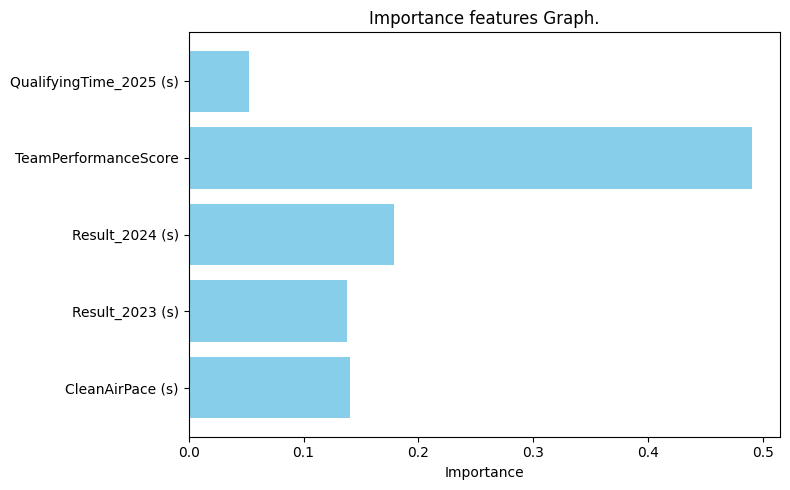

In [ ]:
plt.figure(figsize=(8,5))
plt.barh(features, feature_importance, color='skyblue')
plt.xlabel("Importance")
plt.title("Importance features Graph.")
plt.tight_layout()
plt.show()

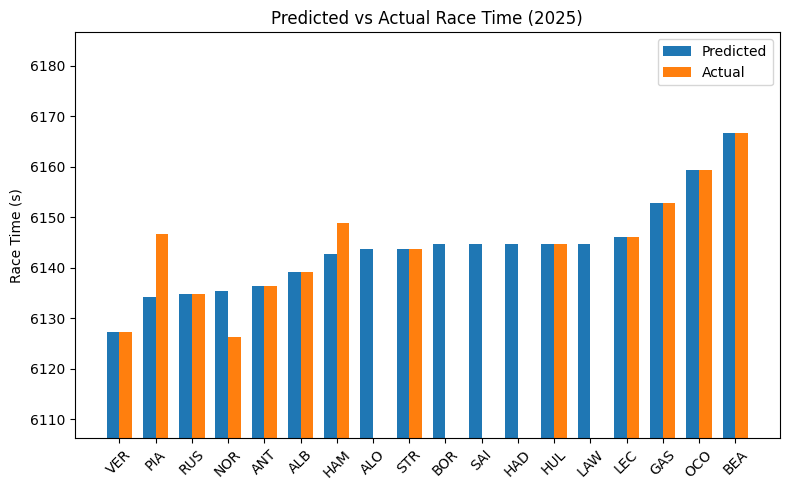

In [374]:
compare = final_results_2025[["Driver", "PredictedTime_2025 (s)", "Result_2025 (s)"]]

drivers = compare["Driver"]
x = np.arange(len(drivers))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, compare["PredictedTime_2025 (s)"], width, label="Predicted")
plt.bar(x + width/2, compare["Result_2025 (s)"], width, label="Actual")

plt.ylim(compare[["PredictedTime_2025 (s)", "Result_2025 (s)"]].min().min() - 20,
         compare[["PredictedTime_2025 (s)", "Result_2025 (s)"]].max().max() + 20)
plt.xticks(x, drivers, rotation=45)
plt.ylabel("Race Time (s)")
plt.title("Predicted vs Actual Race Time (2025)")
plt.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_190312/668619087.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  compare["Error (s)"] = compare["PredictedTime_2025 (s)"] - compare["Result_2025 (s)"]


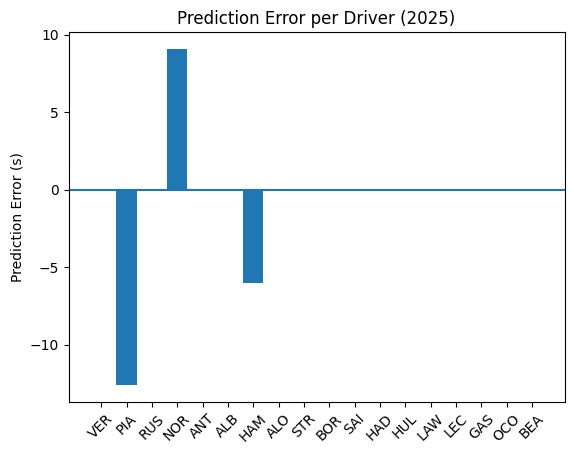

In [375]:
compare["Error (s)"] = compare["PredictedTime_2025 (s)"] - compare["Result_2025 (s)"]

plt.figure()

plt.bar(compare["Driver"], compare["Error (s)"])

plt.xticks(rotation=45)
plt.ylabel("Prediction Error (s)")
plt.title("Prediction Error per Driver (2025)")

plt.axhline(0)

plt.show()

# 2026 Prediction

In [243]:
qualifying_data_2026 = fastf1.get_session(2026,'Australia','Q')
qualifying_data_2026.load()

Quali_2026 = qualifying_data_2026.laps.pick_quicklaps()
Quali = Quali_2026.groupby("Driver")["LapTime"].min().dt.total_seconds()

qualifying_2026 = Quali.reset_index()
qualifying_2026.columns = ["Driver","QualifyingTime (s)"]

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            IN

In [244]:
qualifying_2026

,Driver,QualifyingTime (s)
0,ALB,80.941
1,ALO,81.969
2,ANT,78.811
3,BEA,80.311
4,BOR,80.221
5,BOT,83.244
6,COL,81.200
7,GAS,80.501
8,HAD,79.303
9,HAM,79.478


In [245]:
practices = {}
pbest_laps = {}

for i in range(1, 4):
    practices[i] = fastf1.get_session(2026, 'Australia', f'FP{i}')
    practices[i].load()

    pbest_laps[i] = (
        practices[i]
        .laps
        .pick_quicklaps()
        .groupby("Driver")["LapTime"]
        .min()
        .dt.total_seconds()
        .rename(f"FP{i}")
    )

practice_2026 = pd.concat(
    [pbest_laps[1], pbest_laps[2], pbest_laps[3]],
    axis=1
)

practice_2026["BestPracticeTime"] = practice_2026.min(axis=1)

core           INFO 	Loading data for Australian Grand Prix - Practice 1 [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading d

In [246]:
practice_2026.reset_index(inplace=True)

In [247]:
practice_2026

,Driver,FP1,FP2,FP3,BestPracticeTime
0,ALB,83.130,81.847,81.664,81.664
1,ANT,81.376,79.943,80.324,79.943
2,BEA,82.682,81.326,80.778,80.778
3,BOR,81.696,81.668,80.459,80.459
4,BOT,84.022,83.660,83.514,83.514
5,COL,83.325,82.619,81.413,81.413
6,GAS,84.035,82.167,81.071,81.071
7,HAD,81.087,80.941,80.137,80.137
8,HAM,80.736,80.050,79.669,79.669
9,HUL,81.969,81.351,81.067,81.067


In [317]:
team_points_2026 = {
    "McLaren":833,
    "Mercedes":469,
    "Red Bull":451,
    "Williams":137,
    "Ferrari":398,
    "Haas":79,
    "Aston Martin":89,
    "Racing Bulls":92,
    "Alpine":22,
    "Audi":00,
    "Cardillac":00
}

In [318]:
teams_2026 = list(team_points_2026.keys())
points_2026 = np.array(list(team_points_2026.values())).reshape(-1,1)

scaler = MinMaxScaler()
scaled_points_2026 = scaler.fit_transform(points_2026)

team_performance_score_2026 = dict(zip(teams_2026, scaled_points_2026.flatten()))

In [324]:
result_2025["Team"] = result_2025["Driver"].map(driver_to_team)

In [325]:
result_2025['TeamPerformanceScore'] = result_2025['Team'].map(team_performance_score_2026)

In [326]:
result_2025

,Driver,RaceTime (s),Team,TeamPerformanceScore
0,NOR,6126.304,McLaren,1.000000
1,PIA,6146.751,McLaren,1.000000
2,VER,6127.199,Red Bull,0.541417
3,HAD,DNF,Red Bull,0.541417
4,LEC,6146.13,Ferrari,0.477791
5,HAM,6148.777,Ferrari,0.477791
6,RUS,6134.785,Mercedes,0.563025
7,ANT,6136.439,Mercedes,0.563025
8,ALO,DNF,Aston Martin,0.106843
9,STR,6143.717,Aston Martin,0.106843


In [327]:
qualifying_2026.set_index("Driver",inplace=True)
practice_2026.set_index("Driver",inplace=True)
result_2023.set_index("Driver",inplace=True)
result_2024.set_index("Driver",inplace=True)
result_2025.set_index("Driver",inplace=True)

result_2025['CleanAirPace (s)'] = practice_2026['BestPracticeTime']
result_2025['Result_2023 (s)'] = result_2023['RaceTime (s)']
result_2025['Result_2024 (s)'] = result_2024['RaceTime (s)']
result_2025['Result_2025 (s)'] = result_2025['RaceTime (s)']
result_2025['QualifyingTime (s)'] = qualifying_2026['QualifyingTime (s)']

qualifying_2026.reset_index(inplace=True)
practice_2026.reset_index(inplace=True)
result_2023.reset_index(inplace=True)
result_2024.reset_index(inplace=True)
result_2025.reset_index(inplace=True)

In [328]:
result_2025

,Driver,RaceTime (s),Team,TeamPerformanceScore,CleanAirPace (s),Result_2023 (s),Result_2024 (s),Result_2025 (s),QualifyingTime (s)
0,NOR,6126.304,McLaren,1.000000,80.443,9162.072,4832.747,6126.304,79.475
1,PIA,6146.751,McLaren,1.000000,79.729,9163.753,4862.613,6146.751,79.380
2,VER,6127.199,Red Bull,0.541417,80.197,9158.371,DNF,6127.199,NaN
3,HAD,DNF,Red Bull,0.541417,80.137,NP,NP,DNF,79.303
4,LEC,6146.13,Ferrari,0.477791,79.827,DNF,4829.209,6146.13,79.327
5,HAM,6148.777,Ferrari,0.477791,79.669,9158.55,DNF,6148.777,79.478
6,RUS,6134.785,Mercedes,0.563025,79.053,DNF,DNF,6134.785,78.518
7,ANT,6136.439,Mercedes,0.563025,79.943,NP,NP,6136.439,78.811
8,ALO,DNF,Aston Martin,0.106843,82.720,9159.14,4927.835,DNF,81.969
9,STR,6143.717,Aston Martin,0.106843,NaN,9161.453,4920.065,6143.717,NaN


In [329]:
result_2025.drop('RaceTime (s)',axis=1,inplace=True)
result_2025['QualifyingTime_2026 (s)'] = result_2025['QualifyingTime (s)']
result_2025.drop('QualifyingTime (s)',axis=1,inplace=True)


In [330]:
final_2026 = result_2025.copy()

In [331]:
final_2026

,Driver,Team,TeamPerformanceScore,CleanAirPace (s),Result_2023 (s),Result_2024 (s),Result_2025 (s),QualifyingTime_2026 (s)
0,NOR,McLaren,1.000000,80.443,9162.072,4832.747,6126.304,79.475
1,PIA,McLaren,1.000000,79.729,9163.753,4862.613,6146.751,79.380
2,VER,Red Bull,0.541417,80.197,9158.371,DNF,6127.199,NaN
3,HAD,Red Bull,0.541417,80.137,NP,NP,DNF,79.303
4,LEC,Ferrari,0.477791,79.827,DNF,4829.209,6146.13,79.327
5,HAM,Ferrari,0.477791,79.669,9158.55,DNF,6148.777,79.478
6,RUS,Mercedes,0.563025,79.053,DNF,DNF,6134.785,78.518
7,ANT,Mercedes,0.563025,79.943,NP,NP,6136.439,78.811
8,ALO,Aston Martin,0.106843,82.720,9159.14,4927.835,DNF,81.969
9,STR,Aston Martin,0.106843,NaN,9161.453,4920.065,6143.717,NaN


In [332]:
final_2026["DNF_2025"] = (final_2026["Result_2025 (s)"]== "DNF").astype(int)
final_2026["NP_2025"] = (final_2026["Result_2025 (s)"]== "NP").astype(int)

final_2026["DNF_2024"] = (final_2026["Result_2024 (s)"]== "DNF").astype(int)
final_2026["NP_2024"] = (final_2026["Result_2024 (s)"]== "NP").astype(int)

final_2026["DNF_2023"] = (final_2026["Result_2023 (s)"]== "DNF").astype(int)
final_2026["NP_2023"] = (final_2026["Result_2023 (s)"]== "NP").astype(int)

In [333]:
final_2026

,Driver,Team,TeamPerformanceScore,CleanAirPace (s),Result_2023 (s),Result_2024 (s),Result_2025 (s),QualifyingTime_2026 (s),DNF_2025,NP_2025,DNF_2024,NP_2024,DNF_2023,NP_2023
0,NOR,McLaren,1.000000,80.443,9162.072,4832.747,6126.304,79.475,0,0,0,0,0,0
1,PIA,McLaren,1.000000,79.729,9163.753,4862.613,6146.751,79.380,0,0,0,0,0,0
2,VER,Red Bull,0.541417,80.197,9158.371,DNF,6127.199,NaN,0,0,1,0,0,0
3,HAD,Red Bull,0.541417,80.137,NP,NP,DNF,79.303,1,0,0,1,0,1
4,LEC,Ferrari,0.477791,79.827,DNF,4829.209,6146.13,79.327,0,0,0,0,1,0
5,HAM,Ferrari,0.477791,79.669,9158.55,DNF,6148.777,79.478,0,0,1,0,0,0
6,RUS,Mercedes,0.563025,79.053,DNF,DNF,6134.785,78.518,0,0,1,0,1,0
7,ANT,Mercedes,0.563025,79.943,NP,NP,6136.439,78.811,0,0,0,1,0,1
8,ALO,Aston Martin,0.106843,82.720,9159.14,4927.835,DNF,81.969,1,0,0,0,0,0
9,STR,Aston Martin,0.106843,NaN,9161.453,4920.065,6143.717,NaN,0,0,0,0,0,0


In [334]:
final_2026['Result_2025 (s)'] = pd.to_numeric(final_2026["Result_2025 (s)"],errors = "coerce")
final_2026['Result_2024 (s)'] = pd.to_numeric(final_2026["Result_2024 (s)"],errors = "coerce")
final_2026['Result_2023 (s)'] = pd.to_numeric(final_2026["Result_2023 (s)"],errors = "coerce")

In [335]:
final_2026

,Driver,Team,TeamPerformanceScore,CleanAirPace (s),Result_2023 (s),Result_2024 (s),Result_2025 (s),QualifyingTime_2026 (s),DNF_2025,NP_2025,DNF_2024,NP_2024,DNF_2023,NP_2023
0,NOR,McLaren,1.000000,80.443,9162.072,4832.747,6126.304,79.475,0,0,0,0,0,0
1,PIA,McLaren,1.000000,79.729,9163.753,4862.613,6146.751,79.380,0,0,0,0,0,0
2,VER,Red Bull,0.541417,80.197,9158.371,NaN,6127.199,NaN,0,0,1,0,0,0
3,HAD,Red Bull,0.541417,80.137,NaN,NaN,NaN,79.303,1,0,0,1,0,1
4,LEC,Ferrari,0.477791,79.827,NaN,4829.209,6146.130,79.327,0,0,0,0,1,0
5,HAM,Ferrari,0.477791,79.669,9158.550,NaN,6148.777,79.478,0,0,1,0,0,0
6,RUS,Mercedes,0.563025,79.053,NaN,NaN,6134.785,78.518,0,0,1,0,1,0
7,ANT,Mercedes,0.563025,79.943,NaN,NaN,6136.439,78.811,0,0,0,1,0,1
8,ALO,Aston Martin,0.106843,82.720,9159.140,4927.835,NaN,81.969,1,0,0,0,0,0
9,STR,Aston Martin,0.106843,NaN,9161.453,4920.065,6143.717,NaN,0,0,0,0,0,0


In [441]:
X_2026 = final_2026[["CleanAirPace (s)","Result_2024 (s)","Result_2025 (s)",
"TeamPerformanceScore","QualifyingTime_2026 (s)"]]

In [442]:
X_2026_imputed = imputer.fit_transform(X_2026)

In [443]:
final_2026 ['PredictedTime_2026 (s)'] = regcv.predict(X_2026_imputed)


In [444]:
final_2026

,Driver,Team,TeamPerformanceScore,CleanAirPace (s),Result_2023 (s),Result_2024 (s),Result_2025 (s),QualifyingTime_2026 (s),DNF_2025,NP_2025,DNF_2024,NP_2024,DNF_2023,NP_2023,PredictedTime_2026 (s)
0,NOR,McLaren,1.000000,80.443,9162.072,4832.747,6126.304,79.475,0,0,0,0,0,0,6161.339844
1,PIA,McLaren,1.000000,79.729,9163.753,4862.613,6146.751,79.380,0,0,0,0,0,0,6161.339844
2,VER,Red Bull,0.541417,80.197,9158.371,NaN,6127.199,NaN,0,0,1,0,0,0,6161.291992
3,HAD,Red Bull,0.541417,80.137,NaN,NaN,NaN,79.303,1,0,0,1,0,1,6161.291992
4,LEC,Ferrari,0.477791,79.827,NaN,4829.209,6146.130,79.327,0,0,0,0,1,0,6161.291992
5,HAM,Ferrari,0.477791,79.669,9158.550,NaN,6148.777,79.478,0,0,1,0,0,0,6161.291992
6,RUS,Mercedes,0.563025,79.053,NaN,NaN,6134.785,78.518,0,0,1,0,1,0,6145.471191
7,ANT,Mercedes,0.563025,79.943,NaN,NaN,6136.439,78.811,0,0,0,1,0,1,6161.291992
8,ALO,Aston Martin,0.106843,82.720,9159.140,4927.835,NaN,81.969,1,0,0,0,0,0,6166.067871
9,STR,Aston Martin,0.106843,NaN,9161.453,4920.065,6143.717,NaN,0,0,0,0,0,0,6166.067871


In [445]:
final_results_2026 = final_2026.sort_values(by=["PredictedTime_2026 (s)", "QualifyingTime_2026 (s)"]).reset_index(drop = True)
final_results_2026

,Driver,Team,TeamPerformanceScore,CleanAirPace (s),Result_2023 (s),Result_2024 (s),Result_2025 (s),QualifyingTime_2026 (s),DNF_2025,NP_2025,DNF_2024,NP_2024,DNF_2023,NP_2023,PredictedTime_2026 (s)
0,RUS,Mercedes,0.563025,79.053,NaN,NaN,6134.785,78.518,0,0,1,0,1,0,6145.471191
1,ANT,Mercedes,0.563025,79.943,NaN,NaN,6136.439,78.811,0,0,0,1,0,1,6161.291992
2,HAD,Red Bull,0.541417,80.137,NaN,NaN,NaN,79.303,1,0,0,1,0,1,6161.291992
3,LEC,Ferrari,0.477791,79.827,NaN,4829.209,6146.130,79.327,0,0,0,0,1,0,6161.291992
4,HAM,Ferrari,0.477791,79.669,9158.550,NaN,6148.777,79.478,0,0,1,0,0,0,6161.291992
5,VER,Red Bull,0.541417,80.197,9158.371,NaN,6127.199,NaN,0,0,1,0,0,0,6161.291992
6,PIA,McLaren,1.000000,79.729,9163.753,4862.613,6146.751,79.380,0,0,0,0,0,0,6161.339844
7,NOR,McLaren,1.000000,80.443,9162.072,4832.747,6126.304,79.475,0,0,0,0,0,0,6161.339844
8,LIN,Racing Bulls,0.110444,80.838,NaN,NaN,NaN,79.971,0,1,0,1,0,1,6166.067871
9,LAW,Racing Bulls,0.110444,80.890,NaN,NaN,NaN,79.994,1,0,0,1,0,1,6166.067871


In [446]:
podium = final_results_2026.loc[:,["Driver","PredictedTime_2026 (s)"]]
print("\n Predicted in the Top 3")
print(f"P1: {podium.iloc[0]['Driver']}")
print(f"P2: {podium.iloc[1]['Driver']}")
print(f"P3: {podium.iloc[2]['Driver']}")

print(f"Model Error (MAE): {mean_absolute_error(y_test, y_pred):.2f} seconds")


 Predicted in the Top 3
P1: RUS
P2: ANT
P3: HAD
Model Error (MAE): 7.31 seconds


In [448]:
feature_importance = regcv.best_estimator_.feature_importances_
features = X_2026.columns

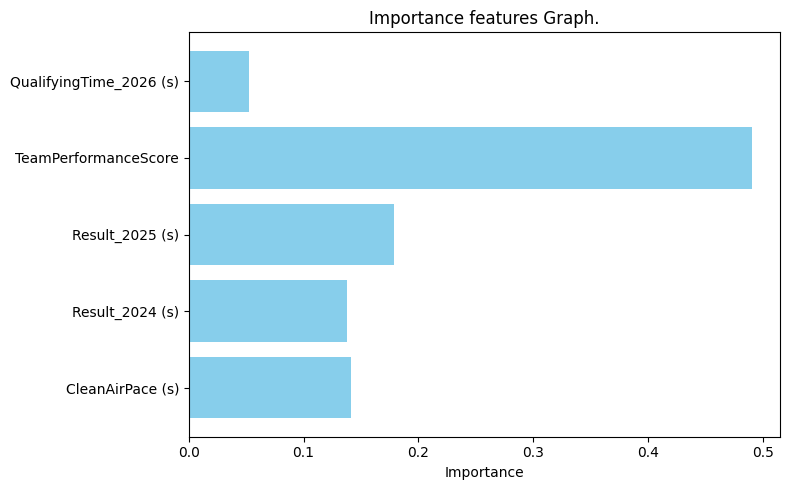

In [449]:
plt.figure(figsize=(8,5))
plt.barh(features, feature_importance, color='skyblue')
plt.xlabel("Importance")
plt.title("Importance features Graph.")
plt.tight_layout()
plt.show()